<a href="https://colab.research.google.com/github/Tauhid-Topu-007/Unet/blob/main/UNET.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import json
import cv2
import numpy as np
import matplotlib.pyplot as plt

from pycocotools import mask as coco_mask

In [3]:
with open('/content/_annotations.coco.json') as f:
  coco_data=json.load(f)
print(coco_data)

{'info': {'year': '2026', 'version': '1', 'description': 'Exported from roboflow.com', 'contributor': '', 'url': 'https://app.roboflow.com/datasets/butterfly-segmentation-cu42k/1', 'date_created': '2026-07-25T15:41:43+00:00'}, 'licenses': [{'id': 1, 'url': '', 'name': 'Private'}], 'categories': [{'id': 0, 'name': 'Butterfly-segmentation', 'supercategory': 'none'}, {'id': 1, 'name': 'Butterfly-segmentation', 'supercategory': 'Butterfly-segmentation'}, {'id': 2, 'name': 'Butterfly-segmentation2', 'supercategory': 'Butterfly-segmentation'}], 'images': [{'id': 0, 'license': 1, 'file_name': 'james-lee-E3R1aMOpLYc-unsplash_jpg.rf.31cc23c6f8fa2ec4f1affb0c680b5145.jpg', 'height': 432, 'width': 432, 'date_captured': '2026-07-25T15:41:43+00:00', 'extra': {'name': 'james-lee-E3R1aMOpLYc-unsplash.jpg'}}, {'id': 1, 'license': 1, 'file_name': 'paul-crook-ZQ43x1Y94j4-unsplash_jpg.rf.7e8af073c3cecd1ae83100b6c9a9949b.jpg', 'height': 432, 'width': 432, 'date_captured': '2026-07-25T15:41:43+00:00', 'extr

In [6]:
image_info=coco_data['images'][0]
print(image_info)

{'id': 0, 'license': 1, 'file_name': 'james-lee-E3R1aMOpLYc-unsplash_jpg.rf.31cc23c6f8fa2ec4f1affb0c680b5145.jpg', 'height': 432, 'width': 432, 'date_captured': '2026-07-25T15:41:43+00:00', 'extra': {'name': 'james-lee-E3R1aMOpLYc-unsplash.jpg'}}


In [7]:
image_path=f"{image_info['file_name']}"
print(image_path)

james-lee-E3R1aMOpLYc-unsplash_jpg.rf.31cc23c6f8fa2ec4f1affb0c680b5145.jpg


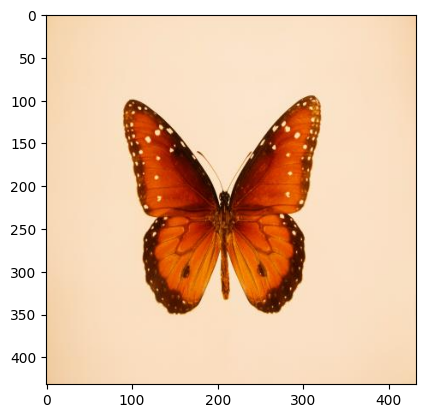

In [8]:
image=cv2.imread(image_path)
image=cv2.cvtColor(image,cv2.COLOR_BGR2RGB)
plt.imshow(image)

In [10]:
coco_data['annotations']

[{'id': 1,
  'image_id': 0,
  'category_id': 1,
  'bbox': [90.65, 95.26, 230.33, 253.8],
  'iscrowd': 0,
  'area': 58457.754,
  'segmentation': [[303.768,
    97.2,
    299.232,
    98.604,
    296.784,
    100.44,
    294.768,
    101.196,
    293.616,
    102.816,
    290.88,
    104.22,
    290.088,
    105.084,
    288.72,
    105.84,
    288.288,
    106.596,
    287.136,
    107.136,
    286.56,
    108.216,
    285.192,
    109.728,
    284.328,
    110.052,
    283.608,
    111.024,
    280.512,
    113.184,
    280.08,
    114.048,
    278.712,
    115.452,
    275.112,
    118.368,
    272.808,
    121.176,
    270,
    123.552,
    267.048,
    127.224,
    265.752,
    128.196,
    265.176,
    129.384,
    263.376,
    131.22,
    262.368,
    133.164,
    260.568,
    134.352,
    258.84,
    137.376,
    255.744,
    141.048,
    254.88,
    142.56,
    254.16,
    142.992,
    253.224,
    144.72,
    252.504,
    145.368,
    250.488,
    148.824,
    248.184,
    151.

In [11]:
image_info

{'id': 0,
 'license': 1,
 'file_name': 'james-lee-E3R1aMOpLYc-unsplash_jpg.rf.31cc23c6f8fa2ec4f1affb0c680b5145.jpg',
 'height': 432,
 'width': 432,
 'date_captured': '2026-07-25T15:41:43+00:00',
 'extra': {'name': 'james-lee-E3R1aMOpLYc-unsplash.jpg'}}

In [12]:
annotations=[ann for ann in coco_data['annotations'] if ann['image_id']==image_info['id']]
annotations

[{'id': 1,
  'image_id': 0,
  'category_id': 1,
  'bbox': [90.65, 95.26, 230.33, 253.8],
  'iscrowd': 0,
  'area': 58457.754,
  'segmentation': [[303.768,
    97.2,
    299.232,
    98.604,
    296.784,
    100.44,
    294.768,
    101.196,
    293.616,
    102.816,
    290.88,
    104.22,
    290.088,
    105.084,
    288.72,
    105.84,
    288.288,
    106.596,
    287.136,
    107.136,
    286.56,
    108.216,
    285.192,
    109.728,
    284.328,
    110.052,
    283.608,
    111.024,
    280.512,
    113.184,
    280.08,
    114.048,
    278.712,
    115.452,
    275.112,
    118.368,
    272.808,
    121.176,
    270,
    123.552,
    267.048,
    127.224,
    265.752,
    128.196,
    265.176,
    129.384,
    263.376,
    131.22,
    262.368,
    133.164,
    260.568,
    134.352,
    258.84,
    137.376,
    255.744,
    141.048,
    254.88,
    142.56,
    254.16,
    142.992,
    253.224,
    144.72,
    252.504,
    145.368,
    250.488,
    148.824,
    248.184,
    151.

In [15]:
mask= np.zeros((image_info['height'],image_info['width']),dtype=np.uint8)
print(mask)

[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


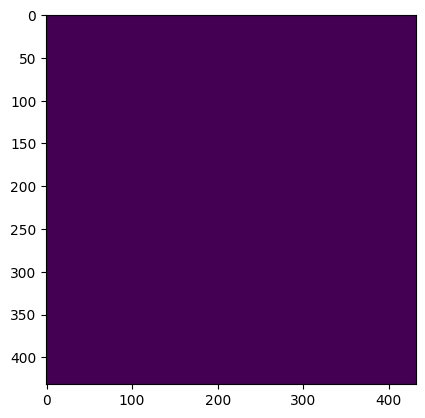

In [16]:
plt.imshow(mask)

In [17]:
segmentation1=[[303.768,
    97.2,
    299.232,
    98.604,
    296.784,
    100.44,
    294.768,
    101.196,
    293.616,
    102.816,
    290.88,
    104.22,
    290.088,
    105.084,
    288.72,
    105.84,
    288.288,
    106.596,
    287.136,
    107.136,
    286.56,
    108.216,
    285.192,
    109.728,
    284.328,
    110.052,
    283.608,
    111.024,
    280.512,
    113.184,
    280.08,
    114.048,
    278.712,
    115.452,
    275.112,
    118.368,
    272.808,
    121.176,
    270,
    123.552,
    267.048,
    127.224,
    265.752,
    128.196,
    265.176,
    129.384,
    263.376,
    131.22,
    262.368,
    133.164,
    260.568,
    134.352,
    258.84,
    137.376,
    255.744,
    141.048,
    254.88,
    142.56,
    254.16,
    142.992,
    253.224,
    144.72,
    252.504,
    145.368,
    250.488,
    148.824,
    248.184,
    151.2,
    247.464,
    152.28,
    247.248,
    153.684,
    245.448,
    155.736,
    244.512,
    157.572,
    242.496,
    160.272,
    241.344,
    161.244,
    241.2,
    162.216,
    240.696,
    162.648,
    240.624,
    164.16,
    238.392,
    167.184,
    238.248,
    168.48,
    237.744,
    169.452,
    236.232,
    169.236,
    235.8,
    169.776,
    235.656,
    171.72,
    235.008,
    173.34,
    233.928,
    175.068,
    232.848,
    176.04,
    232.416,
    177.444,
    230.976,
    179.172,
    229.104,
    182.628,
    227.304,
    185.22,
    226.8,
    187.164,
    225.72,
    189.648,
    224.136,
    191.16,
    221.184,
    197.1,
    220.824,
    199.152,
    220.248,
    200.556,
    219.312,
    201.744,
    217.08,
    207.9,
    216.216,
    211.572,
    215.208,
    213.732,
    212.832,
    212.868,
    211.824,
    210.924,
    211.824,
    209.52,
    212.184,
    209.196,
    210.672,
    209.088,
    210.168,
    209.52,
    209.304,
    211.14,
    208.44,
    209.844,
    207.288,
    209.304,
    206.928,
    208.548,
    206.496,
    208.332,
    205.704,
    208.656,
    204.912,
    209.736,
    203.256,
    210.168,
    202.68,
    212.112,
    202.968,
    213.516,
    202.896,
    215.244,
    204.192,
    218.376,
    204.336,
    219.672,
    204.12,
    220.752,
    203.544,
    221.184,
    203.616,
    222.912,
    202.608,
    223.992,
    202.608,
    224.532,
    203.688,
    225.612,
    203.184,
    226.584,
    202.608,
    226.368,
    201.96,
    225.288,
    201.312,
    225.504,
    200.592,
    226.476,
    200.088,
    226.476,
    199.728,
    225.936,
    199.152,
    224.208,
    199.728,
    223.02,
    199.584,
    221.184,
    200.232,
    219.672,
    199.08,
    217.08,
    199.224,
    214.92,
    198.72,
    212.436,
    197.136,
    212.22,
    198.648,
    211.248,
    198.72,
    210.492,
    197.28,
    209.952,
    196.632,
    209.196,
    196.632,
    207.576,
    195.696,
    203.148,
    194.256,
    202.5,
    193.68,
    201.744,
    193.896,
    200.232,
    192.744,
    197.856,
    191.088,
    197.748,
    190.224,
    194.94,
    189.72,
    194.184,
    190.296,
    192.996,
    189.936,
    191.16,
    188.928,
    190.296,
    188.208,
    188.352,
    187.488,
    187.812,
    186.696,
    186.3,
    185.76,
    185.976,
    184.392,
    184.788,
    183.888,
    182.736,
    182.16,
    180.684,
    182.376,
    179.172,
    181.44,
    178.308,
    180.648,
    176.148,
    178.2,
    174.312,
    176.76,
    172.584,
    175.752,
    171.936,
    174.744,
    170.532,
    174.024,
    170.856,
    173.232,
    172.044,
    172.584,
    171.396,
    171.144,
    170.964,
    170.784,
    169.992,
    169.704,
    168.696,
    169.992,
    167.4,
    169.704,
    165.564,
    170.352,
    164.16,
    168.84,
    160.596,
    168.696,
    159.624,
    167.76,
    159.3,
    167.328,
    158.22,
    166.32,
    157.464,
    165.672,
    155.844,
    165.096,
    155.196,
    163.944,
    154.656,
    162.936,
    153.036,
    160.632,
    151.308,
    159.264,
    148.5,
    157.968,
    147.744,
    158.112,
    146.232,
    157.104,
    145.908,
    155.304,
    144.612,
    154.368,
    142.992,
    153.72,
    140.724,
    152.424,
    139.752,
    151.056,
    137.916,
    150.84,
    137.16,
    147.024,
    135.108,
    145.944,
    132.084,
    144.936,
    131.112,
    144.072,
    129.708,
    143.136,
    129.492,
    141.624,
    127.764,
    139.968,
    127.116,
    138.96,
    125.172,
    137.088,
    124.956,
    135.72,
    122.364,
    134.568,
    121.716,
    132.696,
    119.88,
    131.184,
    120.636,
    129.816,
    118.8,
    129.672,
    117.72,
    129.096,
    118.152,
    128.16,
    118.26,
    127.44,
    116.208,
    126.792,
    115.776,
    125.64,
    116.208,
    125.712,
    117.72,
    125.208,
    118.692,
    124.776,
    118.368,
    124.272,
    117.18,
    123.696,
    116.856,
    123.12,
    117.396,
    122.688,
    118.908,
    121.824,
    119.124,
    121.608,
    117.72,
    122.184,
    115.452,
    123.84,
    115.128,
    124.128,
    113.292,
    123.696,
    112.536,
    122.184,
    112.212,
    120.816,
    110.16,
    118.512,
    109.944,
    117.72,
    110.916,
    117.432,
    110.808,
    116.928,
    109.836,
    115.992,
    109.512,
    115.488,
    108.756,
    116.64,
    107.244,
    115.416,
    106.812,
    114.768,
    105.624,
    113.832,
    105.732,
    113.184,
    106.38,
    111.744,
    104.112,
    110.304,
    103.788,
    108.576,
    104.004,
    107.856,
    103.68,
    107.064,
    103.14,
    105.984,
    101.196,
    102.6,
    101.196,
    102.384,
    101.844,
    101.232,
    102.06,
    99.792,
    100.98,
    98.064,
    101.088,
    97.344,
    101.952,
    96.12,
    102.708,
    94.536,
    105.516,
    93.816,
    105.84,
    93.6,
    106.488,
    92.232,
    108.216,
    91.656,
    110.16,
    91.44,
    111.564,
    91.656,
    113.184,
    90.792,
    114.696,
    91.224,
    116.424,
    91.296,
    120.744,
    90.648,
    123.768,
    91.296,
    125.172,
    90.72,
    126.252,
    90.72,
    127.872,
    92.52,
    132.732,
    92.232,
    133.056,
    92.016,
    134.244,
    92.232,
    136.188,
    92.736,
    137.268,
    92.736,
    138.888,
    93.528,
    142.668,
    93.6,
    144.612,
    94.824,
    146.016,
    95.184,
    148.608,
    95.76,
    150.552,
    96.048,
    153.684,
    97.056,
    155.844,
    98.208,
    160.38,
    98.928,
    161.136,
    98.928,
    162.756,
    100.8,
    165.672,
    100.872,
    167.184,
    102.024,
    168.696,
    101.232,
    169.452,
    101.088,
    170.208,
    102.888,
    174.744,
    102.672,
    175.716,
    102.672,
    179.388,
    103.752,
    183.492,
    104.544,
    185.22,
    104.472,
    186.732,
    105.624,
    188.244,
    105.768,
    189.108,
    106.2,
    189.648,
    105.552,
    190.188,
    105.264,
    191.376,
    105.48,
    192.78,
    106.2,
    194.076,
    106.56,
    197.208,
    107.136,
    198.612,
    106.992,
    200.556,
    107.208,
    202.068,
    108,
    204.12,
    110.088,
    204.768,
    109.224,
    205.308,
    108.792,
    206.388,
    107.208,
    205.848,
    107.424,
    207.792,
    108.072,
    208.656,
    109.008,
    209.196,
    107.928,
    209.952,
    107.856,
    212.22,
    108.72,
    214.272,
    110.448,
    216.756,
    110.232,
    218.268,
    110.88,
    218.916,
    111.744,
    222.048,
    113.112,
    222.372,
    113.328,
    222.696,
    112.968,
    224.208,
    113.832,
    225.072,
    114.696,
    227.124,
    116.28,
    227.232,
    115.704,
    227.664,
    115.704,
    228.744,
    116.208,
    230.148,
    117.936,
    231.012,
    119.16,
    231.012,
    120.528,
    233.28,
    122.184,
    234.684,
    123.624,
    235.224,
    125.136,
    234.9,
    127.008,
    235.224,
    128.16,
    234.684,
    129.672,
    234.576,
    130.464,
    234.9,
    131.256,
    235.764,
    132.696,
    235.98,
    132.768,
    238.248,
    133.344,
    237.276,
    134.352,
    237.276,
    134.784,
    237.708,
    134.352,
    238.464,
    133.416,
    238.68,
    133.128,
    239.328,
    132.192,
    239.652,
    131.184,
    240.732,
    130.032,
    240.732,
    130.248,
    241.164,
    130.104,
    242.352,
    128.664,
    242.676,
    128.016,
    243.756,
    126.864,
    243.972,
    125.208,
    245.16,
    125.136,
    246.672,
    124.056,
    248.724,
    122.688,
    249.696,
    122.472,
    251.316,
    120.528,
    252.504,
    118.944,
    254.124,
    118.584,
    255.312,
    117.72,
    255.636,
    117.792,
    257.148,
    115.632,
    260.172,
    115.56,
    261.144,
    115.128,
    261.9,
    114.48,
    264.384,
    114.696,
    267.192,
    115.992,
    269.244,
    115.488,
    270.648,
    114.696,
    271.188,
    114.12,
    273.564,
    114.48,
    277.56,
    114.12,
    279.828,
    114.624,
    281.232,
    113.832,
    284.148,
    113.976,
    288.792,
    114.48,
    290.52,
    115.704,
    291.6,
    116.712,
    293.22,
    116.136,
    294.408,
    116.208,
    295.488,
    118.44,
    295.38,
    119.232,
    295.596,
    119.808,
    296.244,
    119.16,
    297,
    117.72,
    297.324,
    117.36,
    297.756,
    117.504,
    299.592,
    118.224,
    300.672,
    117.36,
    303.48,
    117.648,
    304.992,
    117.504,
    307.476,
    117.72,
    310.824,
    118.656,
    311.256,
    119.16,
    312.012,
    119.376,
    314.064,
    119.88,
    315.576,
    121.608,
    316.764,
    122.688,
    319.356,
    123.552,
    319.896,
    125.064,
    320.004,
    125.352,
    320.328,
    126.072,
    323.244,
    126,
    324.756,
    126.864,
    326.592,
    128.52,
    327.78,
    128.52,
    328.536,
    128.808,
    329.184,
    128.664,
    331.02,
    128.232,
    332.208,
    129.24,
    332.532,
    129.744,
    333.828,
    131.184,
    333.504,
    132.48,
    336.744,
    134.064,
    337.068,
    134.784,
    337.824,
    136.296,
    338.472,
    138.744,
    341.28,
    140.112,
    342.036,
    141.768,
    344.196,
    142.2,
    345.708,
    142.992,
    347.22,
    144.144,
    347.868,
    144.72,
    348.732,
    148.104,
    348.948,
    149.256,
    348.3,
    149.904,
    348.84,
    150.84,
    349.056,
    152.208,
    348.408,
    155.448,
    348.3,
    156.384,
    348.84,
    158.256,
    348.408,
    159.768,
    348.948,
    161.136,
    348.192,
    162.792,
    348.732,
    163.584,
    347.544,
    164.88,
    346.788,
    165.672,
    346.68,
    167.112,
    345.816,
    168.912,
    345.708,
    169.344,
    344.52,
    170.352,
    344.196,
    170.712,
    343.332,
    172.224,
    342.792,
    172.8,
    341.928,
    175.752,
    339.768,
    177.624,
    337.932,
    178.272,
    336.852,
    178.704,
    335.124,
    179.424,
    334.044,
    180.144,
    333.612,
    180.936,
    331.776,
    181.728,
    330.696,
    181.728,
    329.184,
    182.808,
    326.808,
    184.176,
    324.756,
    184.176,
    323.352,
    185.112,
    321.516,
    185.544,
    320.004,
    186.84,
    318.816,
    186.768,
    317.196,
    188.208,
    314.928,
    188.64,
    313.2,
    189.72,
    311.364,
    190.296,
    309.636,
    190.8,
    306.72,
    190.656,
    303.696,
    191.232,
    302.184,
    191.088,
    300.564,
    191.232,
    300.348,
    191.376,
    301.428,
    191.88,
    301.752,
    192.672,
    301.752,
    193.536,
    300.672,
    193.392,
    300.024,
    192.672,
    299.16,
    192.816,
    298.836,
    194.904,
    296.028,
    195.768,
    295.488,
    196.128,
    294.624,
    196.272,
    293.22,
    197.28,
    291.492,
    197.496,
    289.98,
    198.72,
    289.224,
    198.864,
    288.792,
    198.648,
    287.82,
    197.712,
    287.172,
    198.648,
    286.632,
    199.08,
    285.768,
    198.864,
    284.148,
    199.512,
    282.852,
    199.08,
    281.232,
    200.088,
    279.504,
    199.872,
    278.748,
    198.72,
    278.532,
    198.504,
    278.208,
    201.672,
    277.992,
    202.752,
    276.696,
    203.256,
    273.996,
    203.976,
    275.184,
    203.688,
    276.696,
    204.912,
    278.1,
    204.408,
    279.612,
    204.984,
    281.232,
    204.552,
    282.528,
    204.84,
    284.148,
    204.624,
    285.876,
    204.768,
    286.524,
    205.272,
    287.064,
    204.696,
    288.252,
    204.696,
    288.9,
    205.2,
    289.656,
    205.344,
    290.412,
    204.696,
    291.708,
    204.048,
    300.672,
    204.264,
    301.968,
    204.048,
    303.912,
    204.48,
    305.1,
    204.12,
    306.72,
    204.624,
    308.124,
    204.408,
    309.852,
    204.768,
    311.148,
    204.552,
    312.552,
    204.84,
    314.172,
    204.696,
    316.008]]

In [18]:
for seg in segmentation1:
  print(np.array(seg).reshape(len(seg)//2,2))

[[303.768  97.2  ]
 [299.232  98.604]
 [296.784 100.44 ]
 [294.768 101.196]
 [293.616 102.816]
 [290.88  104.22 ]
 [290.088 105.084]
 [288.72  105.84 ]
 [288.288 106.596]
 [287.136 107.136]
 [286.56  108.216]
 [285.192 109.728]
 [284.328 110.052]
 [283.608 111.024]
 [280.512 113.184]
 [280.08  114.048]
 [278.712 115.452]
 [275.112 118.368]
 [272.808 121.176]
 [270.    123.552]
 [267.048 127.224]
 [265.752 128.196]
 [265.176 129.384]
 [263.376 131.22 ]
 [262.368 133.164]
 [260.568 134.352]
 [258.84  137.376]
 [255.744 141.048]
 [254.88  142.56 ]
 [254.16  142.992]
 [253.224 144.72 ]
 [252.504 145.368]
 [250.488 148.824]
 [248.184 151.2  ]
 [247.464 152.28 ]
 [247.248 153.684]
 [245.448 155.736]
 [244.512 157.572]
 [242.496 160.272]
 [241.344 161.244]
 [241.2   162.216]
 [240.696 162.648]
 [240.624 164.16 ]
 [238.392 167.184]
 [238.248 168.48 ]
 [237.744 169.452]
 [236.232 169.236]
 [235.8   169.776]
 [235.656 171.72 ]
 [235.008 173.34 ]
 [233.928 175.068]
 [232.848 176.04 ]
 [232.416 17

In [19]:
def create_binary_mask(segmentations,image_height,image_width):
  mask_temp=np.zeros((image_height,image_width),dtype=np.uint8)
  for seg in segmentations:
    poly=np.array(seg).reshape(len(seg)//2,2)
    cv2.fillPoly(mask_temp,[np.int32(poly)],1)
  return mask_temp

for ann in annotations:
  #we need to go through the annotations and create a mask
  #update the mask
  binary_mask=create_binary_mask(ann['segmentation'],image_info['height'], image_info['width'])
  mask=np.maximum(mask,binary_mask)
